# Final Results and Dissertation Report Figures

This notebook is the portable reporting entry point. It runs without
the raw UK-DALE dataset or trained model artifacts by using the frozen
reference tables bundled with the source-code submission.


## 1. Load and validate the frozen reference results

In [11]:
# ============================================================
# LOAD FROZEN REPORTING RESULTS
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ------------------------------------------------------------
# 1. Fixed project location
# ------------------------------------------------------------

BUNDLE_ROOT = Path(
    "/content/drive/MyDrive/dissertation/submission_bundle"
)

assert BUNDLE_ROOT.exists(), (
    f"Bundle folder not found:\n{BUNDLE_ROOT}"
)

assert (BUNDLE_ROOT / "README.md").exists(), (
    f"README.md not found inside:\n{BUNDLE_ROOT}"
)

assert (BUNDLE_ROOT / "results").exists(), (
    f"results/ folder not found inside:\n{BUNDLE_ROOT}"
)


# ------------------------------------------------------------
# 2. Reporting directories
# ------------------------------------------------------------

REFERENCE_DIR = (
    BUNDLE_ROOT
    / "results"
    / "reference_outputs"
)

FIGURE_DIR = (
    BUNDLE_ROOT
    / "results"
    / "generated_report_figures"
)

TABLE_DIR = (
    BUNDLE_ROOT
    / "results"
    / "generated_report_tables"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. Fixed reporting configuration
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

DISPLAY_NAMES = {
    "kettle": "Kettle",
    "cold_appliance": "Cold appliance",
    "dishwasher": "Dishwasher",
    "laundry_appliance": "Laundry appliance",
    "microwave": "Microwave",
}

SOURCE_STAGE = "source_temporal_test"

# Keep the internal stored label unchanged.
EXTERNAL_STAGE = "unseen_house_5"

FINAL_VARIANT = "Experiment 4"


# ------------------------------------------------------------
# 4. Required frozen reference tables
# ------------------------------------------------------------

required_files = {
    "policy": "final_estimator_policy.csv",
    "postprocessing": "final_postprocessing_policy.csv",
    "detail": "final_untouched_house_level_results.csv",
    "macro": "final_untouched_macro_results.csv",
    "deltas": "final_untouched_deltas.csv",
    "overall": "final_untouched_overall.csv",
}

missing = [
    filename
    for filename in required_files.values()
    if not (REFERENCE_DIR / filename).exists()
]

assert not missing, (
    "Missing bundled reference tables:\n"
    + "\n".join(missing)
)


# ------------------------------------------------------------
# 5. Load frozen tables
# ------------------------------------------------------------

tables = {
    key: pd.read_csv(
        REFERENCE_DIR / filename
    )
    for key, filename in required_files.items()
}

policy_df = tables["policy"]
postprocessing_df = tables["postprocessing"]
detail_df = tables["detail"]
macro_df = tables["macro"]
deltas_df = tables["deltas"]
overall_df = tables["overall"]


# ------------------------------------------------------------
# 6. Validate frozen reporting data
# ------------------------------------------------------------

assert set(policy_df["category"]) == set(CATEGORIES)

assert set(
    postprocessing_df["category"]
) == set(CATEGORIES)

assert set(
    detail_df["evaluation_stage"]
) == {
    SOURCE_STAGE,
    EXTERNAL_STAGE,
}

assert {
    "Incumbent",
    FINAL_VARIANT,
}.issubset(
    set(detail_df["variant"])
)


# ------------------------------------------------------------
# 7. Figure defaults
# ------------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})


# ------------------------------------------------------------
# 8. Confirmation
# ------------------------------------------------------------

configuration_df = pd.DataFrame({
    "item": [
        "Bundle root",
        "Reference tables",
        "Figure output",
        "Table output",
        "Final variant",
    ],
    "value": [
        str(BUNDLE_ROOT),
        str(REFERENCE_DIR),
        str(FIGURE_DIR),
        str(TABLE_DIR),
        FINAL_VARIANT,
    ],
})


display(configuration_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebook 02 reporting environment loaded successfully.



,item,value
0,Bundle root,/content/drive/MyDrive/dissertation/submission...
1,Reference tables,/content/drive/MyDrive/dissertation/submission...
2,Figure output,/content/drive/MyDrive/dissertation/submission...
3,Table output,/content/drive/MyDrive/dissertation/submission...
4,Final variant,Experiment 4


## 2. Leakage-controlled experimental protocol

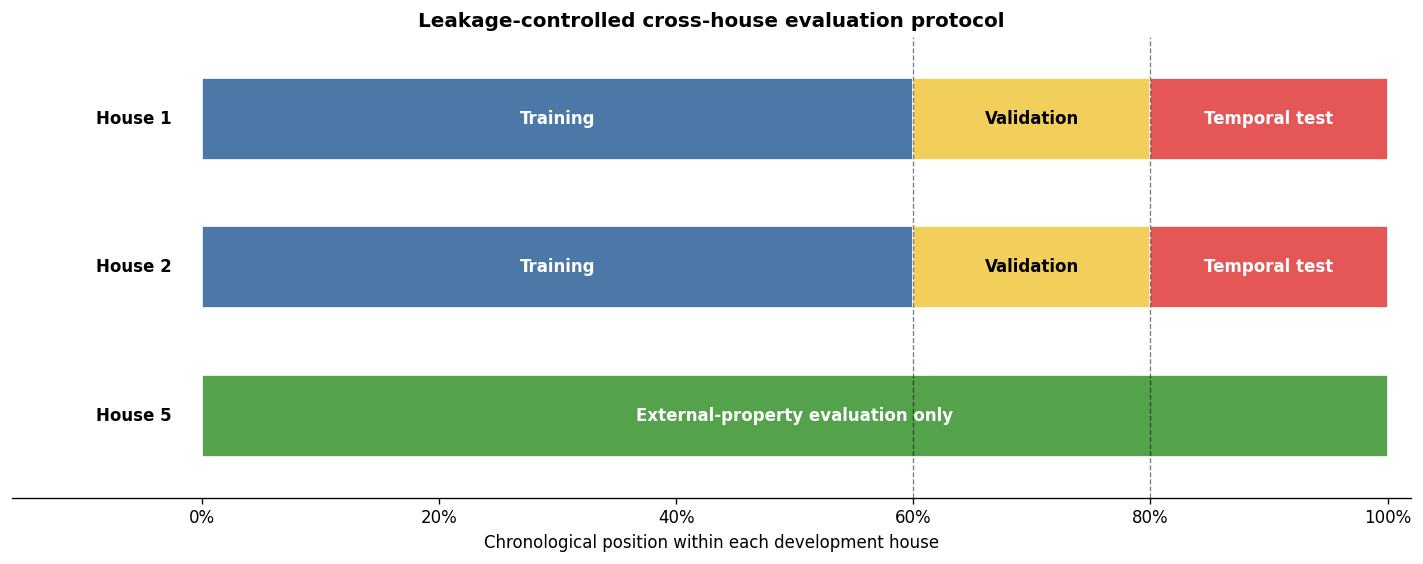

In [13]:
fig, ax = plt.subplots(figsize=(12, 4.8))

rows = [("House 1", 3.0), ("House 2", 2.0)]
colours = ["#4C78A8", "#F2CF5B", "#E45756"]
segments = [(0.00, 0.60, "Training"), (0.60, 0.20, "Validation"), (0.80, 0.20, "Temporal test")]

for label, y in rows:
    for (start, width, text), colour in zip(segments, colours):
        ax.barh(y, width, left=start, height=0.55, color=colour, edgecolor="white")
        ax.text(start + width / 2, y, text, ha="center", va="center", color="white" if text != "Validation" else "black", weight="bold")
    ax.text(-0.025, y, label, ha="right", va="center", weight="bold")

ax.barh(1.0, 1.0, left=0.0, height=0.55, color="#54A24B", edgecolor="white")
ax.text(0.5, 1.0, "External evaluation only", ha="center", va="center", color="white", weight="bold")
ax.text(-0.025, 1.0, "House 5", ha="right", va="center", weight="bold")

ax.axvline(0.60, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0.80, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlim(-0.16, 1.02)
ax.set_ylim(0.45, 3.55)
ax.set_yticks([])
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.set_xlabel("Chronological position within each development house")
ax.set_title("Leakage-controlled cross-house evaluation protocol", weight="bold")
ax.spines["left"].set_visible(False)
fig.tight_layout()

protocol_path = FIGURE_DIR / "figure_01_experimental_protocol.png"
fig.savefig(protocol_path, bbox_inches="tight")
plt.show()

## 3. Final cross-house performance

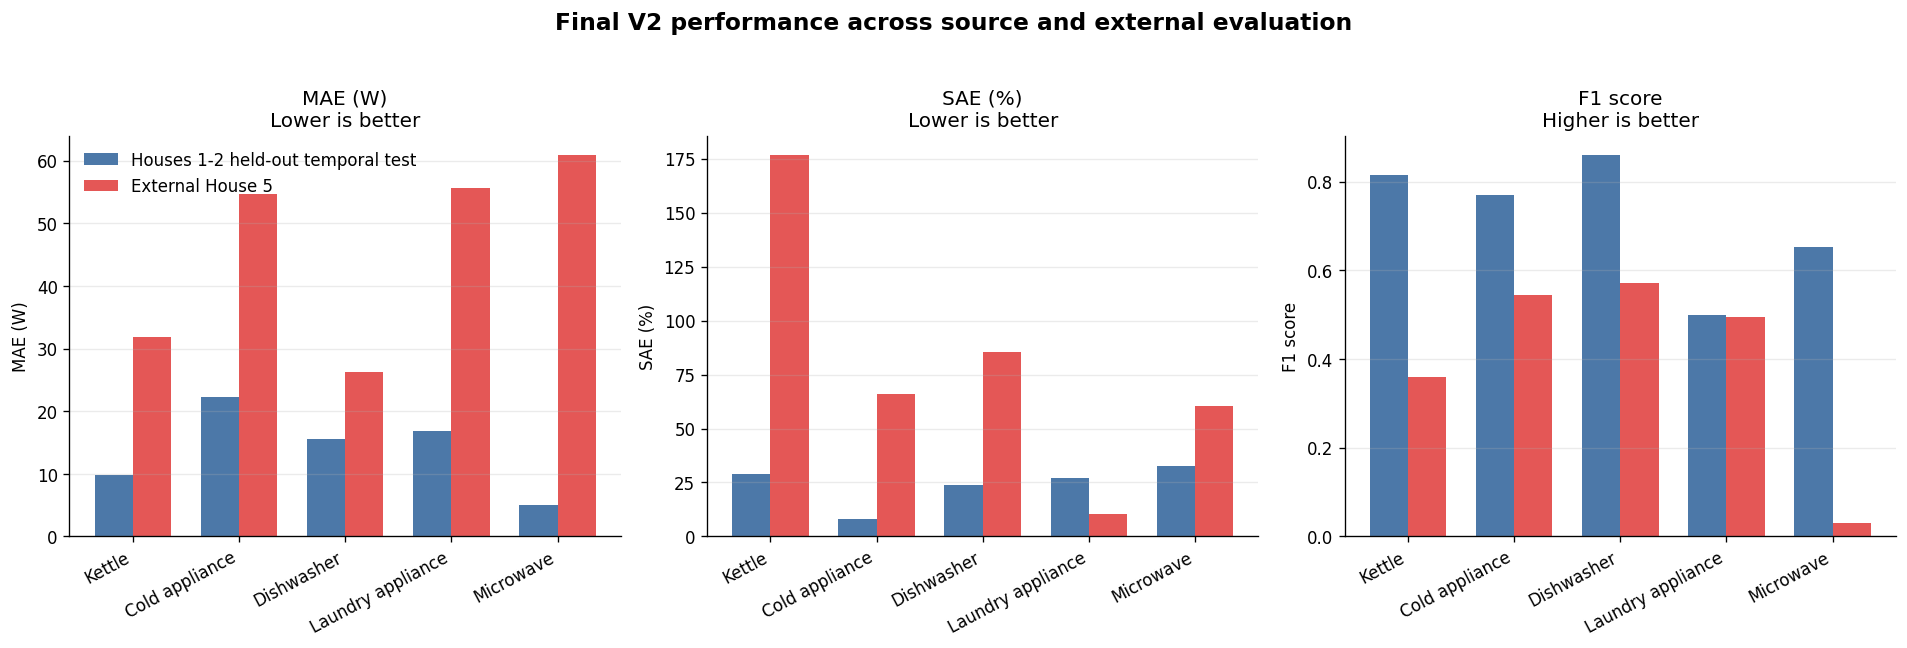

In [15]:
final_macro = macro_df[macro_df["variant"] == FINAL_VARIANT].copy()
final_macro["category"] = pd.Categorical(final_macro["category"], CATEGORIES, ordered=True)
final_macro = final_macro.sort_values(["evaluation_stage", "category"])

stage_labels = {
    SOURCE_STAGE: "Houses 1-2 held-out temporal test",
    EXTERNAL_STAGE: "External House 5",
}
stage_colours = {SOURCE_STAGE: "#4C78A8", EXTERNAL_STAGE: "#E45756"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
metrics = [("mae_w", "MAE (W)", "Lower is better"), ("sae_pct", "SAE (%)", "Lower is better"), ("f1_score", "F1 score", "Higher is better")]
x = np.arange(len(CATEGORIES))
width = 0.36

for axis, (column, ylabel, subtitle) in zip(axes, metrics):
    for offset, stage in zip([-width / 2, width / 2], [SOURCE_STAGE, EXTERNAL_STAGE]):
        stage_frame = final_macro[final_macro["evaluation_stage"] == stage].set_index("category").reindex(CATEGORIES)
        axis.bar(x + offset, stage_frame[column], width, label=stage_labels[stage], color=stage_colours[stage])
    axis.set_title(f"{ylabel}\n{subtitle}")
    axis.set_xticks(x)
    axis.set_xticklabels([DISPLAY_NAMES[c] for c in CATEGORIES], rotation=28, ha="right")
    axis.set_ylabel(ylabel)
    axis.grid(axis="y", alpha=0.25)

axes[0].legend(loc="upper left")
fig.suptitle("Final V2 performance across source and external evaluation", fontsize=14, weight="bold", y=1.03)
fig.tight_layout()

performance_path = FIGURE_DIR / "figure_02_final_cross_house_performance.png"
fig.savefig(performance_path, bbox_inches="tight")
plt.show()

final_macro.to_csv(TABLE_DIR / "table_final_macro_results.csv", index=False)

## 4. Generalisation gap

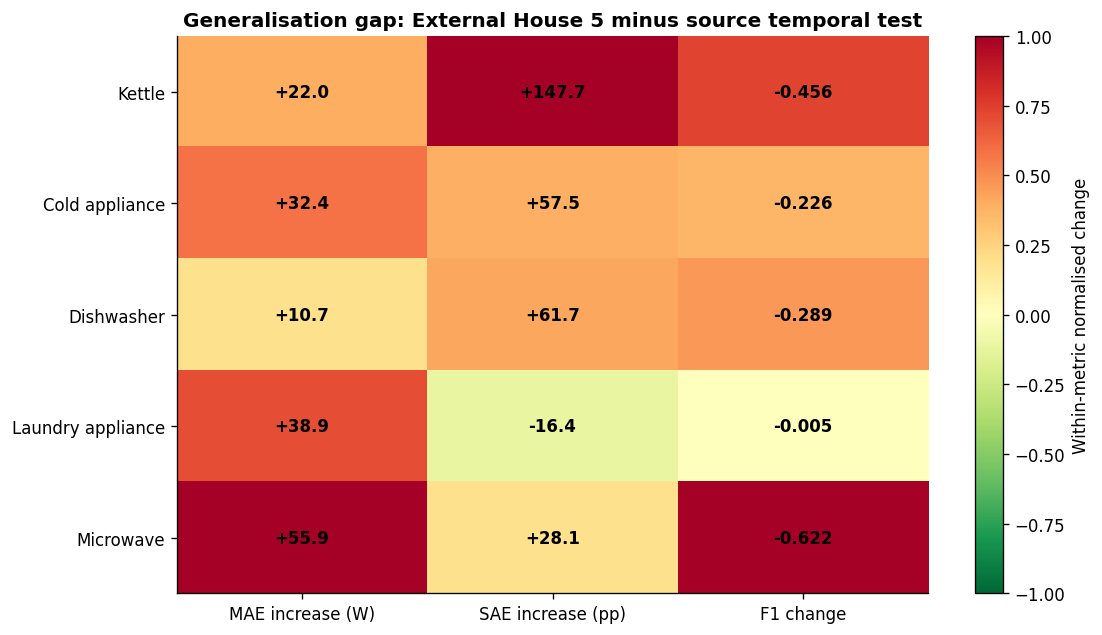

In [16]:
source = final_macro[final_macro["evaluation_stage"] == SOURCE_STAGE].set_index("category")
external = final_macro[final_macro["evaluation_stage"] == EXTERNAL_STAGE].set_index("category")

gap_df = pd.DataFrame({
    "MAE increase (W)": external["mae_w"] - source["mae_w"],
    "SAE increase (pp)": external["sae_pct"] - source["sae_pct"],
    "F1 change": external["f1_score"] - source["f1_score"],
}).reindex(CATEGORIES)

normalised = gap_df.copy()
for column in normalised.columns:
    scale = max(float(normalised[column].abs().max()), 1e-12)
    normalised[column] = normalised[column] / scale

# For colour semantics, red must always indicate deterioration. Increases in
# MAE/SAE are harmful, whereas decreases in F1 are harmful.
normalised["F1 change"] = -normalised["F1 change"]

fig, ax = plt.subplots(figsize=(9.5, 5.4))
image = ax.imshow(normalised.to_numpy(), cmap="RdYlGn_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(gap_df.columns)))
ax.set_xticklabels(gap_df.columns)
ax.set_yticks(range(len(CATEGORIES)))
ax.set_yticklabels([DISPLAY_NAMES[c] for c in CATEGORIES])

for row in range(len(CATEGORIES)):
    for column in range(len(gap_df.columns)):
        value = gap_df.iloc[row, column]
        label = f"{value:+.3f}" if "F1" in gap_df.columns[column] else f"{value:+.1f}"
        ax.text(column, row, label, ha="center", va="center", weight="bold")

ax.set_title("Generalisation gap: External House 5 minus source temporal test", weight="bold")
fig.colorbar(image, ax=ax, label="Within-metric normalised change")
fig.tight_layout()

gap_path = FIGURE_DIR / "figure_03_generalisation_gap_heatmap.png"
fig.savefig(gap_path, bbox_inches="tight")
plt.show()

gap_df.reset_index(names="category").to_csv(TABLE_DIR / "table_generalisation_gap.csv", index=False)

## 5. Effect of causal post-processing

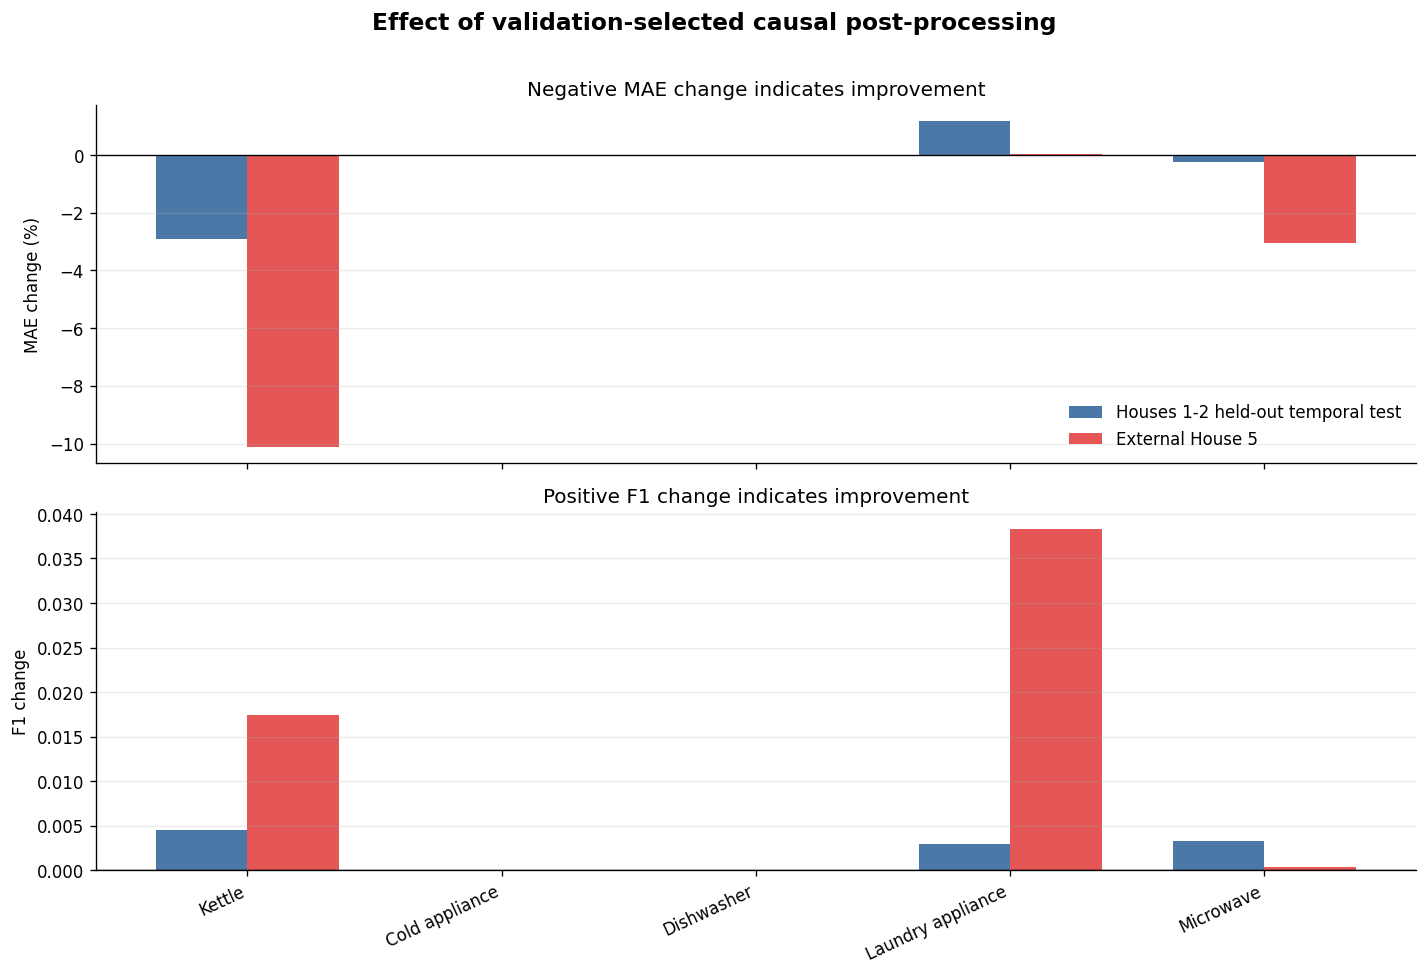

In [17]:
plot_deltas = deltas_df.copy()
plot_deltas["category"] = pd.Categorical(plot_deltas["category"], CATEGORIES, ordered=True)
plot_deltas = plot_deltas.sort_values(["evaluation_stage", "category"])

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
x = np.arange(len(CATEGORIES))
width = 0.36

for offset, stage in zip([-width / 2, width / 2], [SOURCE_STAGE, EXTERNAL_STAGE]):
    frame = plot_deltas[plot_deltas["evaluation_stage"] == stage].set_index("category").reindex(CATEGORIES)
    axes[0].bar(x + offset, frame["mae_change_pct"], width, label=stage_labels[stage], color=stage_colours[stage])
    axes[1].bar(x + offset, frame["f1_change"], width, label=stage_labels[stage], color=stage_colours[stage])

axes[0].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("MAE change (%)")
axes[1].set_ylabel("F1 change")
axes[0].set_title("Negative MAE change indicates improvement")
axes[1].set_title("Positive F1 change indicates improvement")
axes[1].set_xticks(x)
axes[1].set_xticklabels([DISPLAY_NAMES[c] for c in CATEGORIES], rotation=25, ha="right")
axes[0].legend(loc="best")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)

fig.suptitle("Effect of validation-selected causal post-processing", fontsize=14, weight="bold", y=1.01)
fig.tight_layout()

postprocessing_path = FIGURE_DIR / "figure_04_postprocessing_effect.png"
fig.savefig(postprocessing_path, bbox_inches="tight")
plt.show()

## 6. Actual versus predicted appliance energy

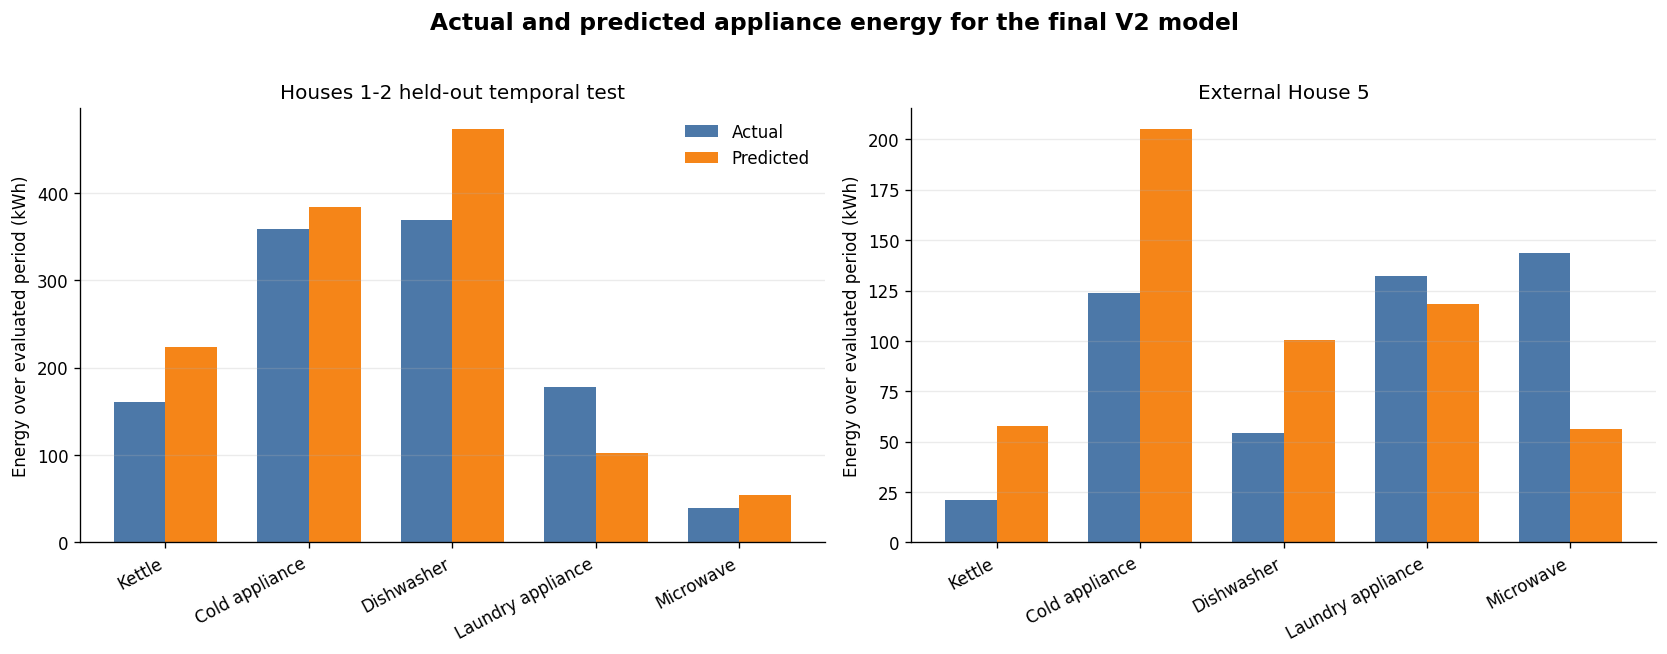

In [18]:
energy = detail_df[detail_df["variant"] == FINAL_VARIANT].copy()
energy_summary = (
    energy.groupby(["evaluation_stage", "category"], as_index=False)
    .agg(actual_energy_kwh=("actual_energy_kwh", "sum"), predicted_energy_kwh=("predicted_energy_kwh", "sum"))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3), sharey=False)
x = np.arange(len(CATEGORIES))
width = 0.36

for axis, stage in zip(axes, [SOURCE_STAGE, EXTERNAL_STAGE]):
    frame = energy_summary[energy_summary["evaluation_stage"] == stage].set_index("category").reindex(CATEGORIES)
    axis.bar(x - width / 2, frame["actual_energy_kwh"], width, label="Actual", color="#4C78A8")
    axis.bar(x + width / 2, frame["predicted_energy_kwh"], width, label="Predicted", color="#F58518")
    axis.set_xticks(x)
    axis.set_xticklabels([DISPLAY_NAMES[c] for c in CATEGORIES], rotation=28, ha="right")
    axis.set_ylabel("Energy over evaluated period (kWh)")
    axis.set_title(stage_labels[stage])
    axis.grid(axis="y", alpha=0.25)

axes[0].legend(loc="best")
fig.suptitle("Actual and predicted appliance energy for the final V2 model", fontsize=14, weight="bold", y=1.02)
fig.tight_layout()

energy_path = FIGURE_DIR / "figure_05_actual_vs_predicted_energy.png"
fig.savefig(energy_path, bbox_inches="tight")
plt.show()

energy_summary.to_csv(TABLE_DIR / "table_actual_vs_predicted_energy.csv", index=False)

## 7. Frozen estimator and post-processing policy

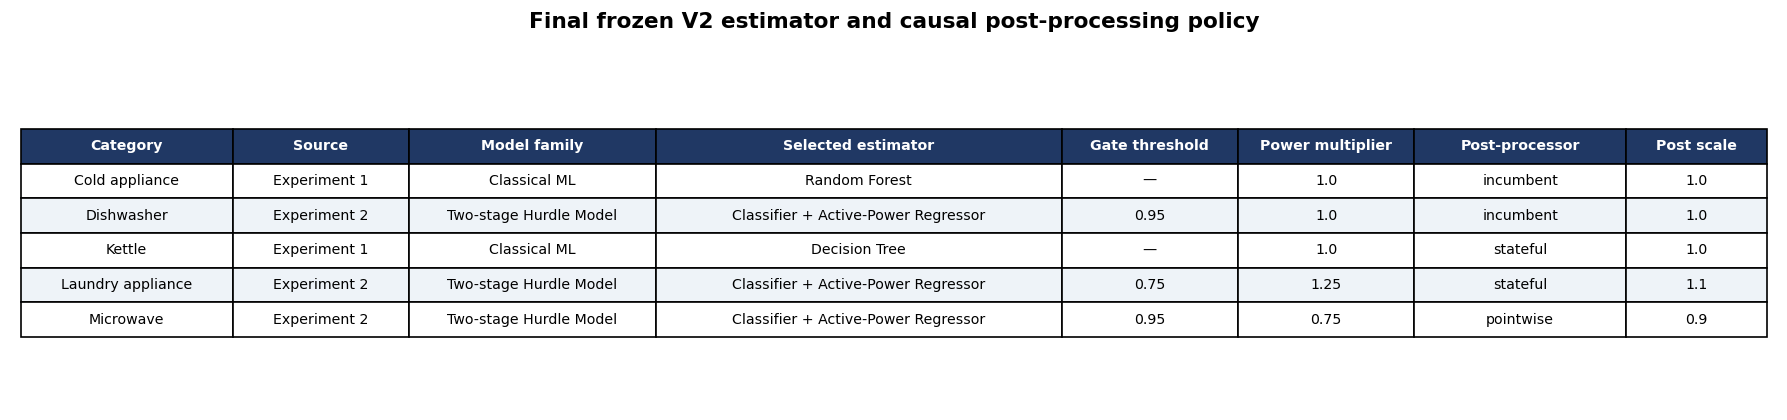

In [19]:
policy_display = policy_df[["category", "source_experiment", "model_family", "selected_model", "probability_threshold", "power_multiplier"]].copy()
policy_display = policy_display.merge(
    postprocessing_df[["category", "processor_mode", "power_scale"]],
    on="category",
    how="left",
)
policy_display["category"] = policy_display["category"].map(DISPLAY_NAMES)

fig, ax = plt.subplots(figsize=(15, 3.6))
ax.axis("off")
display_frame = policy_display.fillna("—").copy()
display_frame.columns = [
    "Category", "Source", "Model family", "Selected estimator",
    "Gate threshold", "Power multiplier", "Post-processor", "Post scale",
]
table = ax.table(
    cellText=display_frame.astype(str).values,
    colLabels=display_frame.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.12, 0.10, 0.14, 0.23, 0.10, 0.10, 0.12, 0.08],
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.65)
for (row, column), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#203864")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EEF3F8")
ax.set_title("Final frozen V2 estimator and causal post-processing policy", fontsize=13, weight="bold", pad=18)
fig.tight_layout()

policy_path = FIGURE_DIR / "figure_06_final_model_policy.png"
fig.savefig(policy_path, bbox_inches="tight")
plt.show()

policy_display.to_csv(TABLE_DIR / "table_final_model_policy.csv", index=False)

## 8. Headline results and generated-file manifest

In [20]:
headline = overall_df[overall_df["variant"] == FINAL_VARIANT].copy()
headline["evaluation_stage"] = headline["evaluation_stage"].map(stage_labels)
headline = headline[["evaluation_stage", "mean_mae_w", "mean_sae_pct", "mean_f1_score"]]
headline.columns = ["Evaluation stage", "Mean MAE (W)", "Mean SAE (%)", "Mean F1"]

figure_manifest = pd.DataFrame({
    "figure": [
        "Experimental protocol",
        "Final cross-house performance",
        "Generalisation-gap heatmap",
        "Post-processing effect",
        "Actual versus predicted energy",
        "Final model policy",
    ],
    "path": [
        protocol_path,
        performance_path,
        gap_path,
        postprocessing_path,
        energy_path,
        policy_path,
    ],
})
figure_manifest["path"] = figure_manifest["path"].astype(str)
figure_manifest.to_csv(TABLE_DIR / "report_figure_manifest.csv", index=False)

print("FINAL RESULTS AND REPORT FIGURES: PASS")
display(headline.round(4))
display(figure_manifest)

FINAL RESULTS AND REPORT FIGURES: PASS


,Evaluation stage,Mean MAE (W),Mean SAE (%),Mean F1
0,Houses 1-2 held-out temporal test,13.8960,24.0936,0.7191
2,External House 5,45.8818,79.8156,0.3995


,figure,path
0,Experimental protocol,/content/drive/MyDrive/dissertation/submission...
1,Final cross-house performance,/content/drive/MyDrive/dissertation/submission...
2,Generalisation-gap heatmap,/content/drive/MyDrive/dissertation/submission...
3,Post-processing effect,/content/drive/MyDrive/dissertation/submission...
4,Actual versus predicted energy,/content/drive/MyDrive/dissertation/submission...
5,Final model policy,/content/drive/MyDrive/dissertation/submission...
